In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV, ElasticNetCV, LinearRegression
# from ngboost import NGBRegressor
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import lasso_path

from utils.eda_utils import EDAUtils, FeatureEngineering, DataCleaningUtils
from utils.ml_utils_v2 import RegressionAnalysis
import joblib

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
eda_utils = EDAUtils()
dcu = DataCleaningUtils()
fe = FeatureEngineering()

In [4]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
PROCESSED_DATA_DIR_PATH = os.path.join(DATA_DIR_PATH, "processed_data")
RESULTS_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "results")
OUTPUT_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "output")
ENSEMBLE_DIR_PATH = os.path.join(OUTPUT_DIR_PATH, "ensemble")
MODELS_DIR_PATH = os.path.join(OUTPUT_DIR_PATH, "models")
TRAINING_DIR_PATH = os.path.join(OUTPUT_DIR_PATH, "training")

# Make sure the output directories exist
os.makedirs(ENSEMBLE_DIR_PATH, exist_ok=True)
os.makedirs(MODELS_DIR_PATH, exist_ok=True)
os.makedirs(TRAINING_DIR_PATH, exist_ok=True)

In [5]:
# Load the emissions data
emissions_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, "total_emissions.csv"))
emissions_df.head()

,iso_alpha_3,income_group,region,year,total_emissions
0,ABW,High income,Latin America & Caribbean,2000,0.335765
1,ABW,High income,Latin America & Caribbean,2001,0.344135
2,ABW,High income,Latin America & Caribbean,2002,0.363222
3,ABW,High income,Latin America & Caribbean,2003,0.412246
4,ABW,High income,Latin America & Caribbean,2004,0.430187


In [6]:
emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4485 entries, 0 to 4484
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   iso_alpha_3      4485 non-null   object 
 1   income_group     4485 non-null   object 
 2   region           4485 non-null   object 
 3   year             4485 non-null   int64  
 4   total_emissions  4485 non-null   float64
dtypes: float64(1), int64(1), object(3)
memory usage: 175.3+ KB


In [7]:
# Load the wb controls
wb_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, "wb_indicators.csv"))
wb_df.head()

,year,pop_total,electricity_from_renewables_pct,renewable_energy_consumption_pct,forest_area_pct,gdp_2015_usd,imports_2015_usd,industry_value_added_2015_usd,manufacturing_value_added_2015_usd,exports_2015_usd,iso_alpha_3
0,2022,731821393.0,NaN,NaN,29.737205,1.040350e+12,3.196559e+11,2.535995e+11,1.016612e+11,2.360208e+11,NaN
1,2021,713090928.0,4.939318,NaN,29.955194,1.004646e+12,2.769094e+11,2.468588e+11,9.989399e+10,2.143081e+11,NaN
2,2020,694446100.0,4.585792,66.123449,30.174252,9.606813e+11,2.448648e+11,2.363776e+11,9.446765e+10,1.958722e+11,NaN
3,2019,675950189.0,5.173796,63.387090,30.391626,9.890095e+11,2.770649e+11,2.482358e+11,1.014837e+11,2.217922e+11,NaN
4,2018,657801085.0,3.945917,62.242631,30.611512,9.677734e+11,2.838657e+11,2.437429e+11,1.002104e+11,2.275611e+11,NaN


In [8]:
wb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6118 entries, 0 to 6117
Data columns (total 11 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   year                                6118 non-null   int64  
 1   pop_total                           6095 non-null   float64
 2   electricity_from_renewables_pct     5617 non-null   float64
 3   renewable_energy_consumption_pct    5710 non-null   float64
 4   forest_area_pct                     5953 non-null   float64
 5   gdp_2015_usd                        5832 non-null   float64
 6   imports_2015_usd                    4449 non-null   float64
 7   industry_value_added_2015_usd       5254 non-null   float64
 8   manufacturing_value_added_2015_usd  4733 non-null   float64
 9   exports_2015_usd                    4413 non-null   float64
 10  iso_alpha_3                         4945 non-null   object 
dtypes: float64(9), int64(1), object(1)
memory u

In [9]:
indicators_and_emissions_df = pd.merge(emissions_df, wb_df, on=["iso_alpha_3", "year"], how="left")
indicators_and_emissions_df.head()

,iso_alpha_3,income_group,region,year,total_emissions,pop_total,electricity_from_renewables_pct,renewable_energy_consumption_pct,forest_area_pct,gdp_2015_usd,imports_2015_usd,industry_value_added_2015_usd,manufacturing_value_added_2015_usd,exports_2015_usd
0,ABW,High income,Latin America & Caribbean,2000,0.335765,90588.0,0.0,0.2,2.333333,2.735727e+09,NaN,NaN,NaN,NaN
1,ABW,High income,Latin America & Caribbean,2001,0.344135,91439.0,0.0,0.2,2.333333,2.850135e+09,NaN,NaN,NaN,NaN
2,ABW,High income,Latin America & Caribbean,2002,0.363222,92074.0,0.0,0.2,2.333333,2.823203e+09,NaN,NaN,NaN,NaN
3,ABW,High income,Latin America & Caribbean,2003,0.412246,93128.0,0.0,0.2,2.333333,2.854554e+09,NaN,NaN,NaN,NaN
4,ABW,High income,Latin America & Caribbean,2004,0.430187,95138.0,0.0,0.2,2.333333,3.062758e+09,NaN,NaN,NaN,NaN


In [10]:
# move total_emissions to the end
indicators_and_emissions_df = indicators_and_emissions_df[[col for col in indicators_and_emissions_df.columns if col != "total_emissions"] + ["total_emissions"]]
indicators_and_emissions_df.head()

,iso_alpha_3,income_group,region,year,pop_total,electricity_from_renewables_pct,renewable_energy_consumption_pct,forest_area_pct,gdp_2015_usd,imports_2015_usd,industry_value_added_2015_usd,manufacturing_value_added_2015_usd,exports_2015_usd,total_emissions
0,ABW,High income,Latin America & Caribbean,2000,90588.0,0.0,0.2,2.333333,2.735727e+09,NaN,NaN,NaN,NaN,0.335765
1,ABW,High income,Latin America & Caribbean,2001,91439.0,0.0,0.2,2.333333,2.850135e+09,NaN,NaN,NaN,NaN,0.344135
2,ABW,High income,Latin America & Caribbean,2002,92074.0,0.0,0.2,2.333333,2.823203e+09,NaN,NaN,NaN,NaN,0.363222
3,ABW,High income,Latin America & Caribbean,2003,93128.0,0.0,0.2,2.333333,2.854554e+09,NaN,NaN,NaN,NaN,0.412246
4,ABW,High income,Latin America & Caribbean,2004,95138.0,0.0,0.2,2.333333,3.062758e+09,NaN,NaN,NaN,NaN,0.430187


In [11]:
indicators_and_emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4485 entries, 0 to 4484
Data columns (total 14 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   iso_alpha_3                         4485 non-null   object 
 1   income_group                        4485 non-null   object 
 2   region                              4485 non-null   object 
 3   year                                4485 non-null   int64  
 4   pop_total                           4462 non-null   float64
 5   electricity_from_renewables_pct     4216 non-null   float64
 6   renewable_energy_consumption_pct    4324 non-null   float64
 7   forest_area_pct                     4402 non-null   float64
 8   gdp_2015_usd                        4317 non-null   float64
 9   imports_2015_usd                    3431 non-null   float64
 10  industry_value_added_2015_usd       4032 non-null   float64
 11  manufacturing_value_added_2015_usd  3743 no

## Data Cleaning

In [12]:
# Fill missing values for numeric columns
indicators_and_emissions_df = dcu.fill_numeric_missing_by_group(indicators_and_emissions_df, ["iso_alpha_3"])

In [13]:
indicators_and_emissions_df.describe()

,year,pop_total,electricity_from_renewables_pct,renewable_energy_consumption_pct,forest_area_pct,gdp_2015_usd,imports_2015_usd,industry_value_added_2015_usd,manufacturing_value_added_2015_usd,exports_2015_usd,total_emissions
count,4485.000000,4.485000e+03,4485.000000,4485.000000,4485.000000,4.485000e+03,4.485000e+03,4.485000e+03,4.485000e+03,4.485000e+03,4485.000000
mean,2011.000000,3.621556e+07,5.026383,31.618974,32.197366,3.471272e+11,1.045265e+11,9.345957e+10,6.058097e+10,1.069587e+11,221.511989
std,6.633989,1.361826e+08,10.405182,30.027298,24.132037,1.496928e+12,2.760113e+11,3.884098e+11,2.862916e+11,2.731760e+11,920.296951
min,2000.000000,1.764800e+04,-71.056856,0.000000,0.000000,1.324972e+08,7.145490e+07,9.434428e+06,1.685068e+06,8.775953e+06,-242.690846
25%,2005.000000,1.504365e+06,0.034592,5.600000,11.073684,6.876350e+09,4.034603e+09,1.449723e+09,5.731685e+08,2.856089e+09,3.405074
50%,2011.000000,7.223805e+06,1.286178,21.600000,30.442858,2.702675e+10,1.441437e+10,7.594740e+09,3.167052e+09,1.240303e+10,36.933154
75%,2017.000000,2.486266e+07,5.805103,53.300000,50.935065,1.796832e+11,7.079266e+10,5.265770e+10,2.542704e+10,7.291426e+10,116.330198
max,2022.000000,1.425423e+09,97.277228,98.300000,95.577213,2.144339e+13,3.542496e+12,6.430542e+12,3.202510e+12,2.456083e+12,14511.221700


In [14]:
# Check which rows have negative electricity_from_renewables_pct
indicators_and_emissions_df[indicators_and_emissions_df["electricity_from_renewables_pct"] < 0]["iso_alpha_3"].unique()

array(['AGO', 'ARG', 'ARM', 'BEN', 'BFA', 'BGD', 'BOL', 'CIV', 'CMR',
       'COD', 'COG', 'COL', 'DZA', 'ECU', 'EGY', 'ETH', 'GAB', 'GEO',
       'GNQ', 'HRV', 'IND', 'IRN', 'IRQ', 'JAM', 'KAZ', 'KEN', 'KGZ',
       'KHM', 'LAO', 'LBN', 'MDG', 'MKD', 'MNG', 'MOZ', 'MYS', 'NAM',
       'NGA', 'NPL', 'PAK', 'PRK', 'PRY', 'SDN', 'SUR', 'TGO', 'TJK',
       'TKM', 'TUN', 'TZA', 'UGA', 'UZB', 'VNM', 'ZAF', 'ZMB'],
      dtype=object)

In [15]:
# Drop electricity_from_renewables_pct column
indicators_and_emissions_df = indicators_and_emissions_df.drop(columns=["electricity_from_renewables_pct"])

In [16]:
# Check negative emissions
negative_emissions_df = indicators_and_emissions_df[indicators_and_emissions_df["total_emissions"] < 0]
negative_emissions_df.iso_alpha_3.unique()

array(['BDI', 'BHS', 'BLZ', 'BTN', 'CAF', 'CMR', 'COG', 'COM', 'DJI',
       'DMA', 'GAB', 'GRD', 'GTM', 'KNA', 'LBR', 'LVA', 'MLI', 'MNG',
       'NAM', 'NER', 'PAN', 'PNG', 'RWA', 'STP', 'SWZ', 'TLS', 'TON',
       'VUT', 'WSM'], dtype=object)

In [17]:
# Drop the negative emissions
indicators_and_emissions_df =indicators_and_emissions_df[indicators_and_emissions_df["total_emissions"] >= 0]

In [18]:
# Check for duplicates
duplicates_df = indicators_and_emissions_df[indicators_and_emissions_df.duplicated(subset=["iso_alpha_3", "year"], keep=False)]
duplicates_df = duplicates_df.sort_values(by=["iso_alpha_3", "year"])
print(f"Duplicates: {duplicates_df.shape[0]}")
print(duplicates_df)

Duplicates: 0
Empty DataFrame
Columns: [iso_alpha_3, income_group, region, year, pop_total, renewable_energy_consumption_pct, forest_area_pct, gdp_2015_usd, imports_2015_usd, industry_value_added_2015_usd, manufacturing_value_added_2015_usd, exports_2015_usd, total_emissions]
Index: []


In [19]:
# Check how many records we have per iso_alpha_3 and create a new df
# with the number of records per iso_alpha_3
iso_alpha_3_counts = indicators_and_emissions_df["iso_alpha_3"].value_counts().reset_index()
iso_alpha_3_counts.columns = ["iso_alpha_3", "count"]
iso_alpha_3_counts = iso_alpha_3_counts.sort_values(by="count", ascending=False)

# how many countries have less than x records?
x = 23
countries_with_less_than_x_records = iso_alpha_3_counts[iso_alpha_3_counts["count"] < x]
print(f"Countries with less than {x} records: {countries_with_less_than_x_records.shape[0]}")
print(countries_with_less_than_x_records)

Countries with less than 23 records: 14
    iso_alpha_3  count
166         GTM     22
167         TLS     22
168         LVA     20
169         MNG     18
170         RWA     17
171         BDI     17
172         GRD     15
173         COG     14
174         KNA     12
175         DJI     10
176         PNG      9
177         PAN      8
178         DMA      6
179         NER      5


In [20]:
# Remove the countries with less than x records from the indicators_and_emissions_df
countries_to_remove = countries_with_less_than_x_records["iso_alpha_3"].tolist()
indicators_and_emissions_df = indicators_and_emissions_df[~indicators_and_emissions_df["iso_alpha_3"].isin(countries_to_remove)]
indicators_and_emissions_df = indicators_and_emissions_df.reset_index(drop=True)

In [21]:
# Check the max year for every country
max_year_df = indicators_and_emissions_df.groupby("iso_alpha_3")["year"].max().reset_index()
max_year_df.columns = ["iso_alpha_3", "max_year"]
max_year_df = max_year_df.sort_values(by="max_year", ascending=False)
print(max_year_df.max_year.unique())

[2022]


In [22]:
indicators_and_emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3818 entries, 0 to 3817
Data columns (total 13 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   iso_alpha_3                         3818 non-null   object 
 1   income_group                        3818 non-null   object 
 2   region                              3818 non-null   object 
 3   year                                3818 non-null   int64  
 4   pop_total                           3818 non-null   float64
 5   renewable_energy_consumption_pct    3818 non-null   float64
 6   forest_area_pct                     3818 non-null   float64
 7   gdp_2015_usd                        3818 non-null   float64
 8   imports_2015_usd                    3818 non-null   float64
 9   industry_value_added_2015_usd       3818 non-null   float64
 10  manufacturing_value_added_2015_usd  3818 non-null   float64
 11  exports_2015_usd                    3818 no

In [23]:
indicators_and_emissions_df.describe()

,year,pop_total,renewable_energy_consumption_pct,forest_area_pct,gdp_2015_usd,imports_2015_usd,industry_value_added_2015_usd,manufacturing_value_added_2015_usd,exports_2015_usd,total_emissions
count,3818.000000,3.818000e+03,3818.000000,3818.000000,3.818000e+03,3.818000e+03,3.818000e+03,3.818000e+03,3.818000e+03,3818.000000
mean,2011.000000,4.175823e+07,28.497669,30.523026,4.061426e+11,1.174562e+11,1.093710e+11,7.097559e+10,1.198367e+11,263.966266
std,6.634118,1.468786e+08,28.742809,23.407427,1.615210e+12,2.945360e+11,4.189506e+11,3.091249e+11,2.904175e+11,991.093662
min,2000.000000,1.764800e+04,0.000000,0.000000,1.324972e+08,1.000002e+08,9.434428e+06,1.685068e+06,8.775953e+06,0.010029
25%,2005.000000,2.518963e+06,4.700000,11.000806,9.754041e+09,5.515070e+09,2.327919e+09,9.057520e+08,4.164145e+09,10.790480
50%,2011.000000,9.201390e+06,17.750000,28.673066,4.157595e+10,1.847410e+10,1.112190e+10,4.967951e+09,1.752229e+10,50.996469
75%,2017.000000,3.042670e+07,46.900000,46.460675,2.107496e+11,8.808246e+10,6.492572e+10,3.636720e+10,9.229121e+10,153.479223
max,2022.000000,1.425423e+09,98.300000,95.577213,2.144339e+13,3.542496e+12,6.430542e+12,3.202510e+12,2.456083e+12,14511.221700


In [24]:
indicators_and_emissions_df.iso_alpha_3.unique().shape

(166,)

## Add Lags

In [25]:
# Make sure the df is sorted by iso_alpha_3 and year
indicators_and_emissions_df_sorted = indicators_and_emissions_df.sort_values(by=["iso_alpha_3", "year"]).reset_index(drop=True)

In [26]:
indicators_and_emissions_df_sorted

,iso_alpha_3,income_group,region,year,pop_total,renewable_energy_consumption_pct,forest_area_pct,gdp_2015_usd,imports_2015_usd,industry_value_added_2015_usd,manufacturing_value_added_2015_usd,exports_2015_usd,total_emissions
0,ABW,High income,Latin America & Caribbean,2000,90588.0,0.2,2.333333,2.735727e+09,2.162352e+09,3.694397e+08,1.062285e+08,2.158564e+09,0.335765
1,ABW,High income,Latin America & Caribbean,2001,91439.0,0.2,2.333333,2.850135e+09,2.162352e+09,3.694397e+08,1.062285e+08,2.158564e+09,0.344135
2,ABW,High income,Latin America & Caribbean,2002,92074.0,0.2,2.333333,2.823203e+09,2.162352e+09,3.694397e+08,1.062285e+08,2.158564e+09,0.363222
3,ABW,High income,Latin America & Caribbean,2003,93128.0,0.2,2.333333,2.854554e+09,2.162352e+09,3.694397e+08,1.062285e+08,2.158564e+09,0.412246
4,ABW,High income,Latin America & Caribbean,2004,95138.0,0.2,2.333333,3.062758e+09,2.162352e+09,3.694397e+08,1.062285e+08,2.158564e+09,0.430187
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3813,ZWE,Lower middle income,Africa Eastern and Southern,2018,15034452.0,79.7,45.332093,2.201518e+10,6.564741e+09,4.817033e+09,2.451550e+09,4.709413e+09,47.509033
3814,ZWE,Lower middle income,Africa Eastern and Southern,2019,15271368.0,81.0,45.213002,2.062108e+10,7.111395e+09,4.403386e+09,2.186755e+09,5.363550e+09,46.442562
3815,ZWE,Lower middle income,Africa Eastern and Southern,2020,15526888.0,84.1,45.093912,1.900914e+10,3.975341e+09,4.040349e+09,1.782311e+09,2.738132e+09,44.576343
3816,ZWE,Lower middle income,Africa Eastern and Southern,2021,15797210.0,82.4,44.974822,2.061884e+10,6.419766e+09,4.297867e+09,1.803676e+09,4.026367e+09,45.759664


In [27]:
training_df_lags = fe.generate_lagged_features(indicators_and_emissions_df_sorted, ["gdp_2015_usd", 
                                                          "imports_2015_usd", 
                                                          "exports_2015_usd", 
                                                          "industry_value_added_2015_usd", 
                                                          "manufacturing_value_added_2015_usd",
                                                          "pop_total"], max_lag=1)

In [28]:
training_df_lags.head()

,iso_alpha_3,income_group,region,year,pop_total,renewable_energy_consumption_pct,forest_area_pct,gdp_2015_usd,imports_2015_usd,industry_value_added_2015_usd,manufacturing_value_added_2015_usd,exports_2015_usd,total_emissions,gdp_2015_usd_lag1,imports_2015_usd_lag1,exports_2015_usd_lag1,industry_value_added_2015_usd_lag1,manufacturing_value_added_2015_usd_lag1,pop_total_lag1
0,ABW,High income,Latin America & Caribbean,2000,90588.0,0.2,2.333333,2.735727e+09,2.162352e+09,3.694397e+08,1.062285e+08,2.158564e+09,0.335765,NaN,NaN,NaN,NaN,NaN,NaN
1,ABW,High income,Latin America & Caribbean,2001,91439.0,0.2,2.333333,2.850135e+09,2.162352e+09,3.694397e+08,1.062285e+08,2.158564e+09,0.344135,2.735727e+09,2.162352e+09,2.158564e+09,3.694397e+08,1.062285e+08,90588.0
2,ABW,High income,Latin America & Caribbean,2002,92074.0,0.2,2.333333,2.823203e+09,2.162352e+09,3.694397e+08,1.062285e+08,2.158564e+09,0.363222,2.850135e+09,2.162352e+09,2.158564e+09,3.694397e+08,1.062285e+08,91439.0
3,ABW,High income,Latin America & Caribbean,2003,93128.0,0.2,2.333333,2.854554e+09,2.162352e+09,3.694397e+08,1.062285e+08,2.158564e+09,0.412246,2.823203e+09,2.162352e+09,2.158564e+09,3.694397e+08,1.062285e+08,92074.0
4,ABW,High income,Latin America & Caribbean,2004,95138.0,0.2,2.333333,3.062758e+09,2.162352e+09,3.694397e+08,1.062285e+08,2.158564e+09,0.430187,2.854554e+09,2.162352e+09,2.158564e+09,3.694397e+08,1.062285e+08,93128.0


In [29]:
training_df_lags.dropna(inplace=True)

In [30]:
training_df_lags.head()

,iso_alpha_3,income_group,region,year,pop_total,renewable_energy_consumption_pct,forest_area_pct,gdp_2015_usd,imports_2015_usd,industry_value_added_2015_usd,manufacturing_value_added_2015_usd,exports_2015_usd,total_emissions,gdp_2015_usd_lag1,imports_2015_usd_lag1,exports_2015_usd_lag1,industry_value_added_2015_usd_lag1,manufacturing_value_added_2015_usd_lag1,pop_total_lag1
1,ABW,High income,Latin America & Caribbean,2001,91439.0,0.2,2.333333,2.850135e+09,2.162352e+09,3.694397e+08,1.062285e+08,2.158564e+09,0.344135,2.735727e+09,2.162352e+09,2.158564e+09,3.694397e+08,1.062285e+08,90588.0
2,ABW,High income,Latin America & Caribbean,2002,92074.0,0.2,2.333333,2.823203e+09,2.162352e+09,3.694397e+08,1.062285e+08,2.158564e+09,0.363222,2.850135e+09,2.162352e+09,2.158564e+09,3.694397e+08,1.062285e+08,91439.0
3,ABW,High income,Latin America & Caribbean,2003,93128.0,0.2,2.333333,2.854554e+09,2.162352e+09,3.694397e+08,1.062285e+08,2.158564e+09,0.412246,2.823203e+09,2.162352e+09,2.158564e+09,3.694397e+08,1.062285e+08,92074.0
4,ABW,High income,Latin America & Caribbean,2004,95138.0,0.2,2.333333,3.062758e+09,2.162352e+09,3.694397e+08,1.062285e+08,2.158564e+09,0.430187,2.854554e+09,2.162352e+09,2.158564e+09,3.694397e+08,1.062285e+08,93128.0
5,ABW,High income,Latin America & Caribbean,2005,97635.0,0.2,2.333333,3.051023e+09,2.162352e+09,3.694397e+08,1.062285e+08,2.158564e+09,0.462648,3.062758e+09,2.162352e+09,2.158564e+09,3.694397e+08,1.062285e+08,95138.0


In [31]:
training_df_lags.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3652 entries, 1 to 3817
Data columns (total 19 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   iso_alpha_3                              3652 non-null   object 
 1   income_group                             3652 non-null   object 
 2   region                                   3652 non-null   object 
 3   year                                     3652 non-null   int64  
 4   pop_total                                3652 non-null   float64
 5   renewable_energy_consumption_pct         3652 non-null   float64
 6   forest_area_pct                          3652 non-null   float64
 7   gdp_2015_usd                             3652 non-null   float64
 8   imports_2015_usd                         3652 non-null   float64
 9   industry_value_added_2015_usd            3652 non-null   float64
 10  manufacturing_value_added_2015_usd       3652 non-nul

## EDA 1

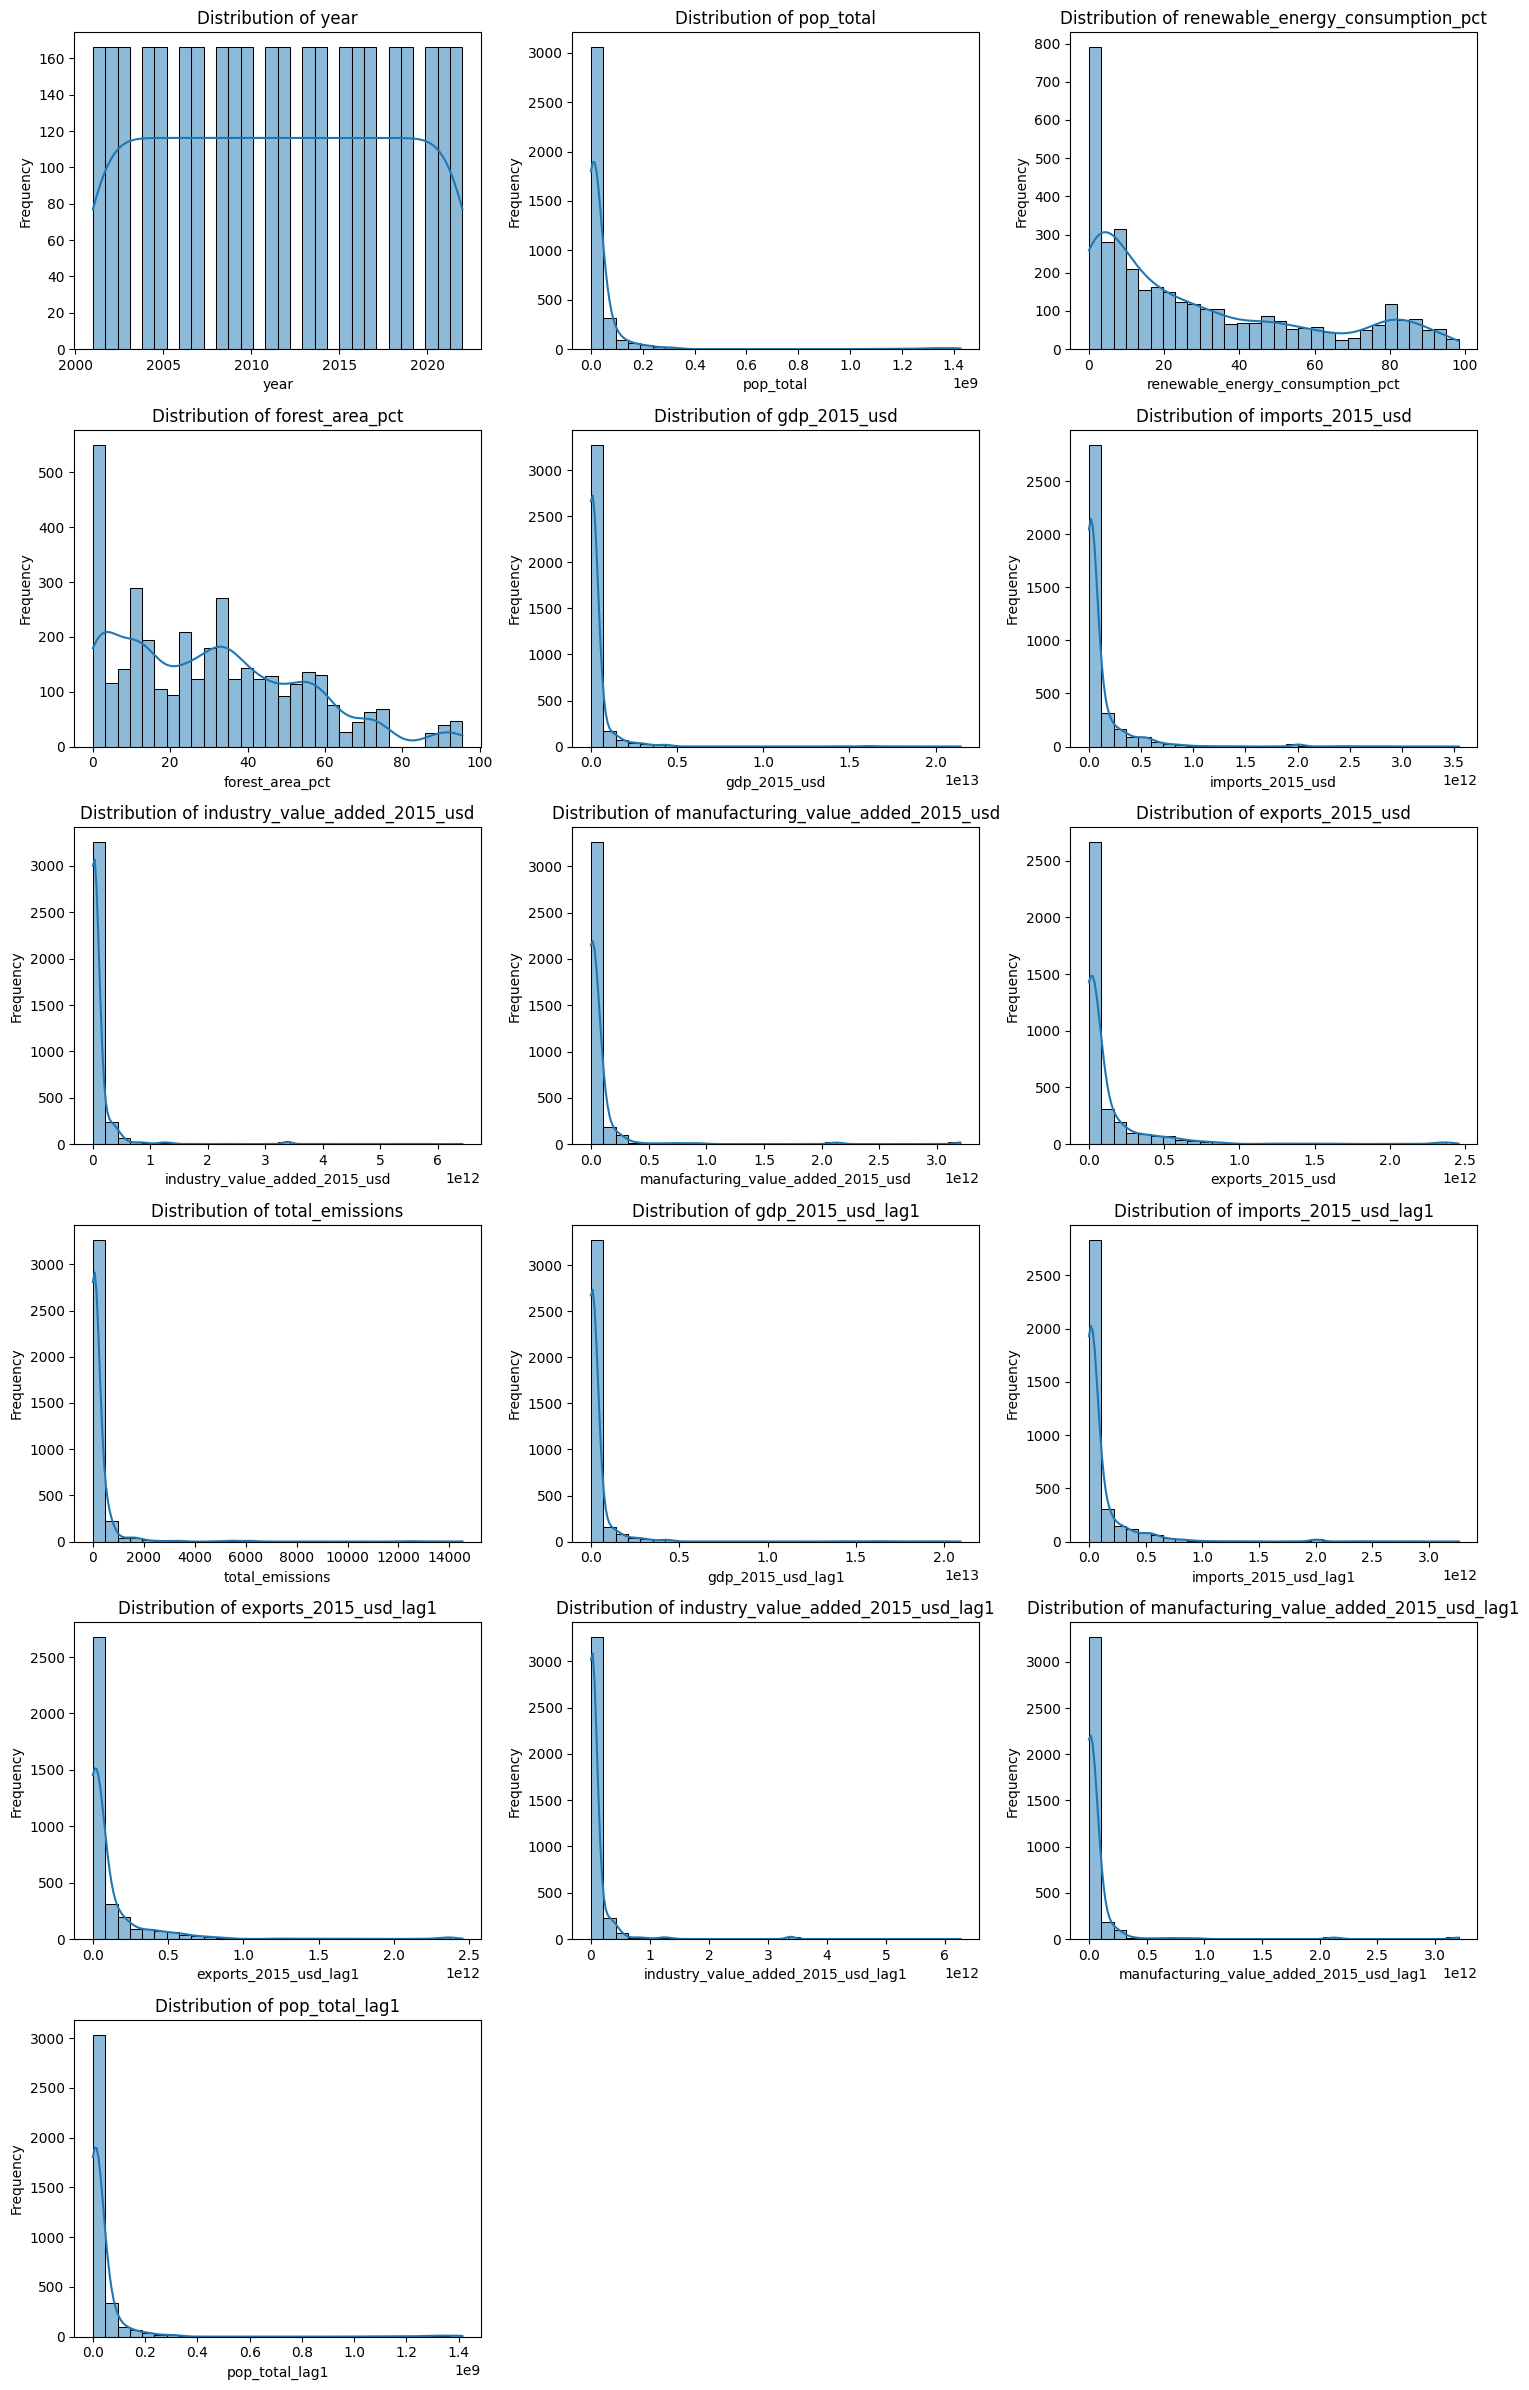

In [32]:
eda_utils.plot_numeric_fields_distributions(training_df_lags)

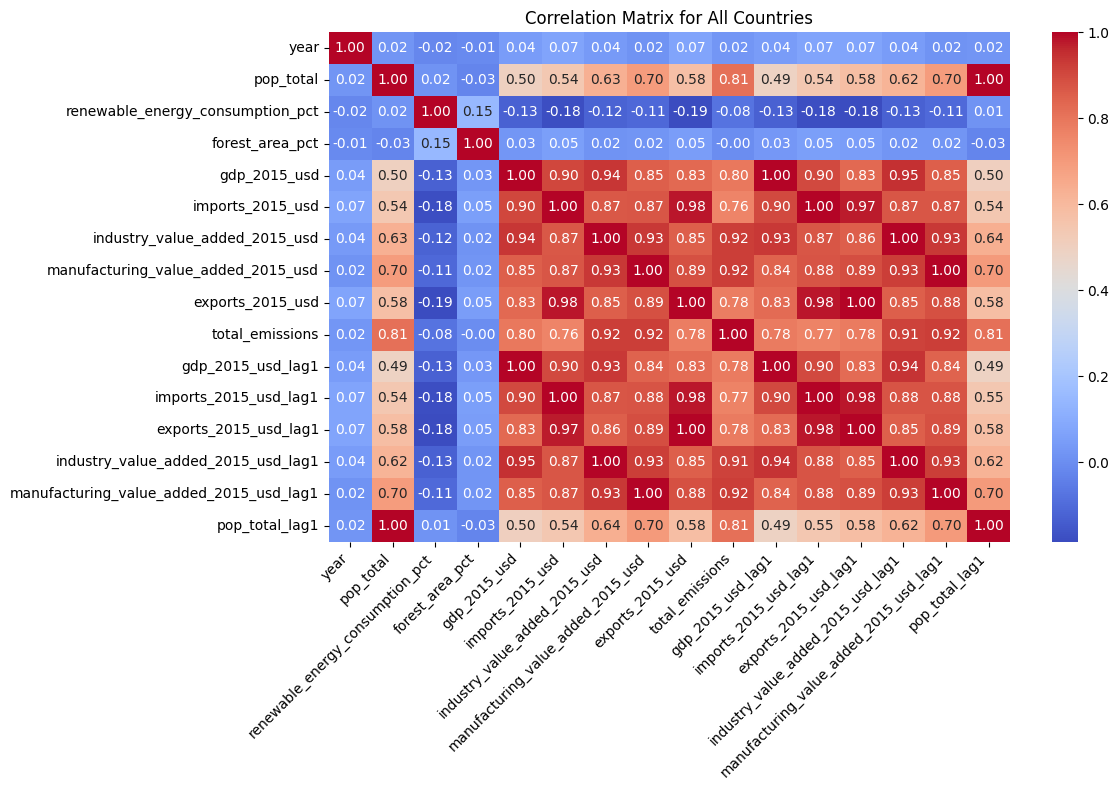

In [33]:
eda_utils.plot_correlation_matrix(training_df_lags, figsize=(12,8))

## Feature Engineering for Numeric Features

In [34]:
# Get the numeric columns
numeric_cols = training_df_lags.select_dtypes(include=["float64", "int64"]).columns.tolist()
numeric_cols_to_drop = ["year"]
numeric_cols = [col for col in numeric_cols if col not in numeric_cols_to_drop]
numeric_cols

['pop_total',
 'renewable_energy_consumption_pct',
 'forest_area_pct',
 'gdp_2015_usd',
 'imports_2015_usd',
 'industry_value_added_2015_usd',
 'manufacturing_value_added_2015_usd',
 'exports_2015_usd',
 'total_emissions',
 'gdp_2015_usd_lag1',
 'imports_2015_usd_lag1',
 'exports_2015_usd_lag1',
 'industry_value_added_2015_usd_lag1',
 'manufacturing_value_added_2015_usd_lag1',
 'pop_total_lag1']

In [35]:
# Log transform the numeric columns with high skewness
training_df_log_transformed = fe.log_transform_high_skew(training_df_lags, numeric_cols, skew_threshold=1.0)
training_df_log_transformed.head()

Columns dropped due to high skewness: ['pop_total', 'gdp_2015_usd', 'imports_2015_usd', 'industry_value_added_2015_usd', 'manufacturing_value_added_2015_usd', 'exports_2015_usd', 'total_emissions', 'gdp_2015_usd_lag1', 'imports_2015_usd_lag1', 'exports_2015_usd_lag1', 'industry_value_added_2015_usd_lag1', 'manufacturing_value_added_2015_usd_lag1', 'pop_total_lag1']


,iso_alpha_3,income_group,region,year,renewable_energy_consumption_pct,forest_area_pct,log_pop_total,log_gdp_2015_usd,log_imports_2015_usd,log_industry_value_added_2015_usd,log_manufacturing_value_added_2015_usd,log_exports_2015_usd,log_total_emissions,log_gdp_2015_usd_lag1,log_imports_2015_usd_lag1,log_exports_2015_usd_lag1,log_industry_value_added_2015_usd_lag1,log_manufacturing_value_added_2015_usd_lag1,log_pop_total_lag1
1,ABW,High income,Latin America & Caribbean,2001,0.2,2.333333,11.423438,21.770632,21.494462,19.727498,18.481103,21.492709,0.295751,21.729663,21.494462,21.492709,19.727498,18.481103,11.414088
2,ABW,High income,Latin America & Caribbean,2002,0.2,2.333333,11.430359,21.761138,21.494462,19.727498,18.481103,21.492709,0.309851,21.770632,21.494462,21.492709,19.727498,18.481103,11.423438
3,ABW,High income,Latin America & Caribbean,2003,0.2,2.333333,11.441741,21.772182,21.494462,19.727498,18.481103,21.492709,0.345181,21.761138,21.494462,21.492709,19.727498,18.481103,11.430359
4,ABW,High income,Latin America & Caribbean,2004,0.2,2.333333,11.463094,21.842582,21.494462,19.727498,18.481103,21.492709,0.357805,21.772182,21.494462,21.492709,19.727498,18.481103,11.441741
5,ABW,High income,Latin America & Caribbean,2005,0.2,2.333333,11.489002,21.838743,21.494462,19.727498,18.481103,21.492709,0.380248,21.842582,21.494462,21.492709,19.727498,18.481103,11.463094


In [36]:
training_df_log_transformed.describe()

,year,renewable_energy_consumption_pct,forest_area_pct,log_pop_total,log_gdp_2015_usd,log_imports_2015_usd,log_industry_value_added_2015_usd,log_manufacturing_value_added_2015_usd,log_exports_2015_usd,log_total_emissions,log_gdp_2015_usd_lag1,log_imports_2015_usd_lag1,log_exports_2015_usd_lag1,log_industry_value_added_2015_usd_lag1,log_manufacturing_value_added_2015_usd_lag1,log_pop_total_lag1
count,3652.000000,3652.000000,3652.000000,3652.000000,3652.000000,3652.000000,3652.000000,3652.000000,3652.000000,3652.000000,3652.000000,3652.000000,3652.000000,3652.000000,3652.000000,3652.000000
mean,2011.500000,28.414047,30.505160,15.742322,24.549953,23.830522,23.135900,22.263473,23.676156,3.791916,24.518541,23.794898,23.645994,23.110070,22.240833,15.728891
std,6.345158,28.636170,23.389084,2.170131,2.138411,1.938449,2.381468,2.662728,2.142871,1.930787,2.139478,1.939736,2.142659,2.382641,2.659156,2.170115
min,2001.000000,0.000000,0.000000,9.778434,18.702072,18.420683,16.059876,14.337317,15.987526,0.009979,18.702072,18.420683,15.987526,16.059876,14.337317,9.778434
25%,2006.000000,4.800000,10.995311,14.757104,23.026356,22.462717,21.572375,20.633662,22.173449,2.477529,22.985895,22.407955,22.122007,21.560559,20.624276,14.734655
50%,2011.500000,17.700000,28.694570,16.038282,24.473709,23.643119,23.141496,22.334882,23.590076,3.952569,24.435525,23.634821,23.554063,23.125899,22.326273,16.021940
75%,2017.000000,46.700000,46.405971,17.238215,26.091825,25.236930,24.904157,24.343946,25.248215,5.051764,26.071027,25.174840,25.248215,24.884484,24.305520,17.218693
max,2022.000000,98.300000,95.551663,21.077735,30.696437,28.895853,29.492080,28.794956,28.529589,9.582746,30.671624,28.813416,28.529589,29.466047,28.794956,21.069833


In [37]:
training_df_log_transformed.isna().sum()

iso_alpha_3                                    0
income_group                                   0
region                                         0
year                                           0
renewable_energy_consumption_pct               0
forest_area_pct                                0
log_pop_total                                  0
log_gdp_2015_usd                               0
log_imports_2015_usd                           0
log_industry_value_added_2015_usd              0
log_manufacturing_value_added_2015_usd         0
log_exports_2015_usd                           0
log_total_emissions                            0
log_gdp_2015_usd_lag1                          0
log_imports_2015_usd_lag1                      0
log_exports_2015_usd_lag1                      0
log_industry_value_added_2015_usd_lag1         0
log_manufacturing_value_added_2015_usd_lag1    0
log_pop_total_lag1                             0
dtype: int64

In [38]:
training_df_lags.isna().sum()

iso_alpha_3                                0
income_group                               0
region                                     0
year                                       0
pop_total                                  0
renewable_energy_consumption_pct           0
forest_area_pct                            0
gdp_2015_usd                               0
imports_2015_usd                           0
industry_value_added_2015_usd              0
manufacturing_value_added_2015_usd         0
exports_2015_usd                           0
total_emissions                            0
gdp_2015_usd_lag1                          0
imports_2015_usd_lag1                      0
exports_2015_usd_lag1                      0
industry_value_added_2015_usd_lag1         0
manufacturing_value_added_2015_usd_lag1    0
pop_total_lag1                             0
dtype: int64

## EDA log transformed data

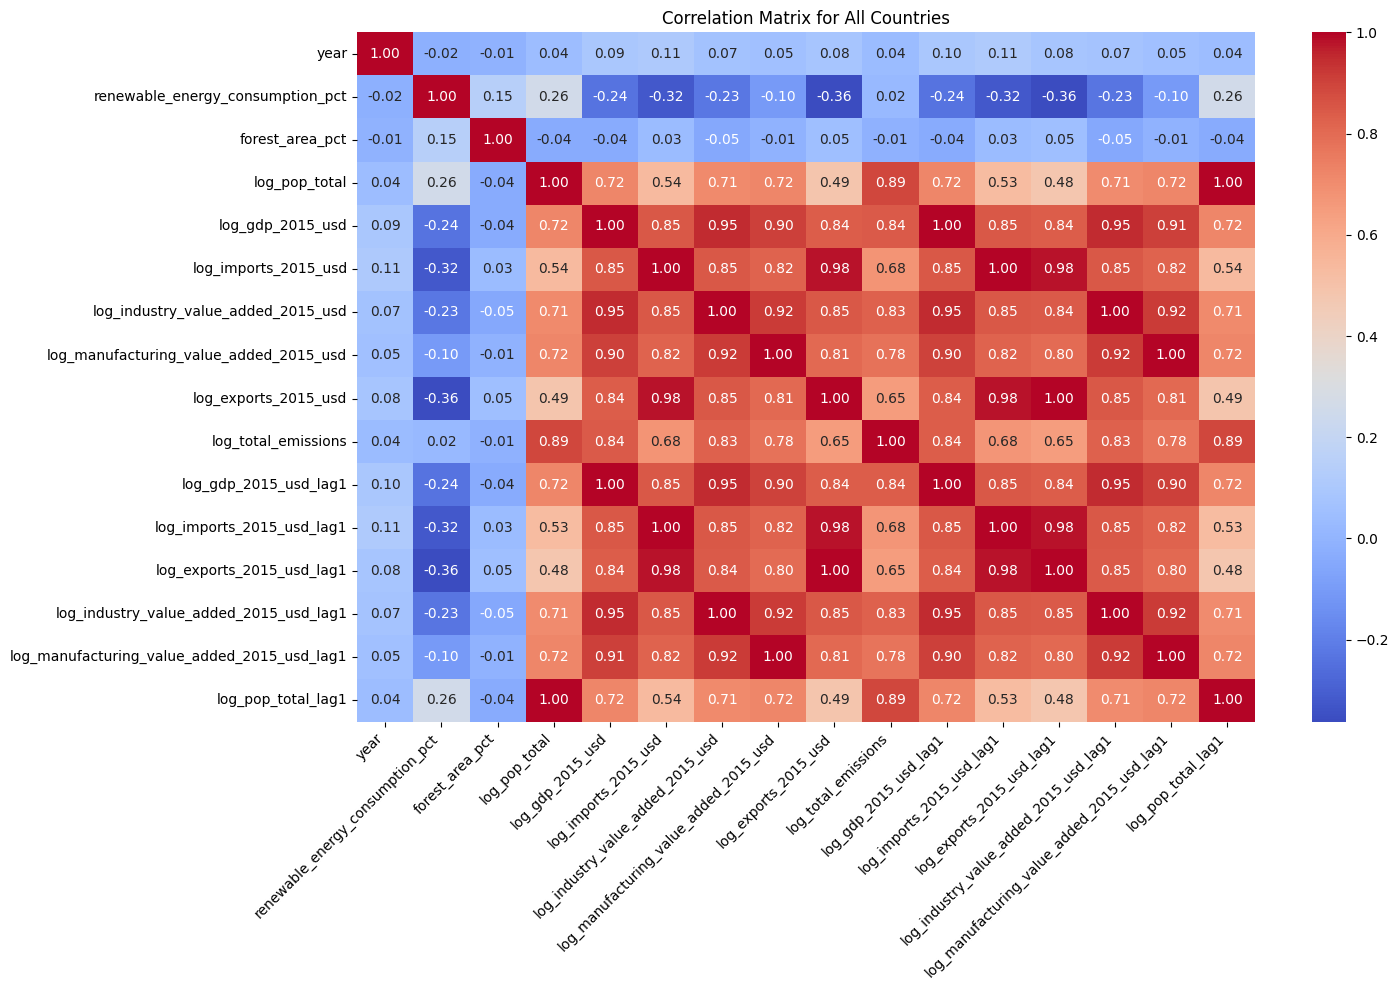

In [39]:
eda_utils.plot_correlation_matrix(training_df_log_transformed, figsize=(15,10))

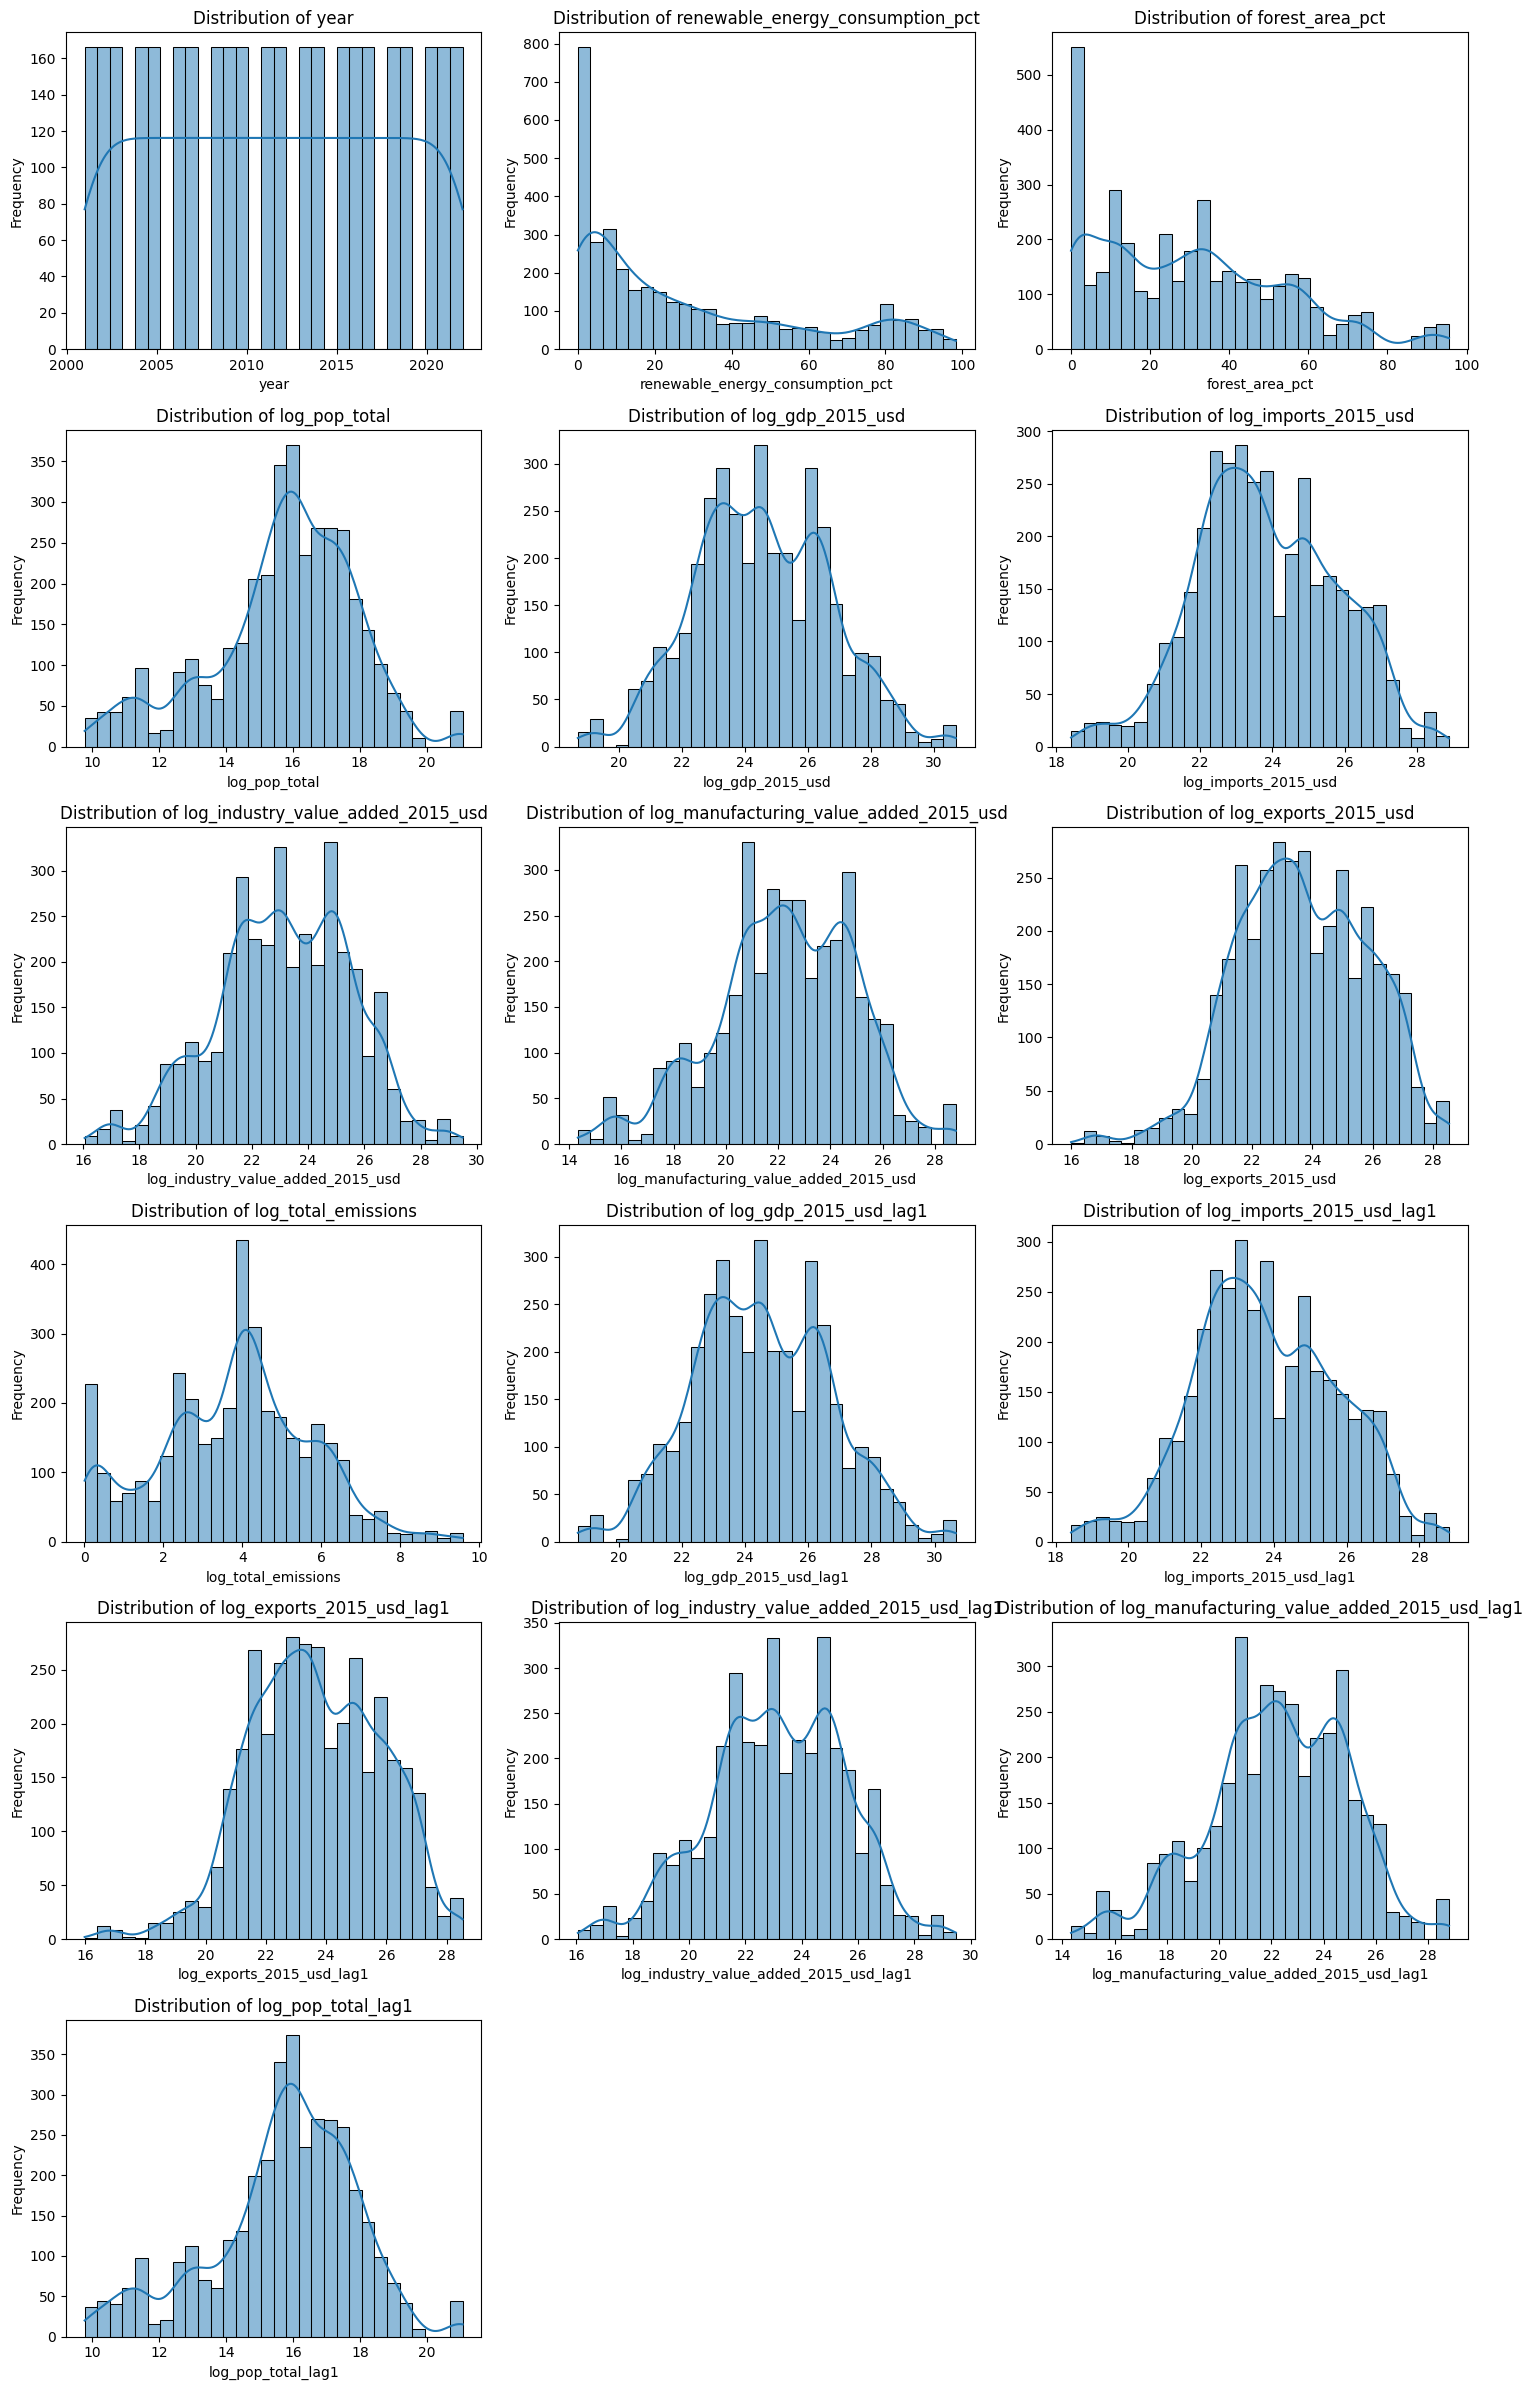

In [40]:
eda_utils.plot_numeric_fields_distributions(training_df_log_transformed)

In [41]:
eda_utils.find_outlier_columns(training_df_log_transformed)

{'log_exports_2015_usd': 0.5750273822562979,
 'log_exports_2015_usd_lag1': 0.5750273822562979}

## ML

In [42]:
training_df_log_transformed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3652 entries, 1 to 3817
Data columns (total 19 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   iso_alpha_3                                  3652 non-null   object 
 1   income_group                                 3652 non-null   object 
 2   region                                       3652 non-null   object 
 3   year                                         3652 non-null   int64  
 4   renewable_energy_consumption_pct             3652 non-null   float64
 5   forest_area_pct                              3652 non-null   float64
 6   log_pop_total                                3652 non-null   float64
 7   log_gdp_2015_usd                             3652 non-null   float64
 8   log_imports_2015_usd                         3652 non-null   float64
 9   log_industry_value_added_2015_usd            3652 non-null   float64
 10  log_m

In [43]:
# Make sure the df is sorted by iso_alpha_3 and year
training_df_log_transformed = training_df_log_transformed.sort_values(by=["iso_alpha_3", "year"]).reset_index(drop=True)

Running regression without group feature...

Cross-Validation Results:
------------------------------------------------------------------------------------------------------------------------
Model              Group MAE    (std)     Time MAE    (std)     Group R2    (std)      Time R2    (std)
------------------------------------------------------------------------------------------------------------------------
RandomForest          0.5648   0.0649       0.6212   0.0401       0.8348   0.0290       0.7875   0.0362
XGBoost               0.5319   0.0190       0.6311   0.0549       0.8645   0.0282       0.7964   0.0430
ElasticNet            0.5582   0.0353       0.6213   0.0464       0.8580   0.0386       0.8194   0.0600
Median                1.5254   0.1554       1.5295   0.1598      -0.0163   0.0178      -0.0417   0.0821

Evaluation Results:
--------------------------------------------------------------------------------
Model            Train MAE   Test MAE   Train R2    Test R2
-----

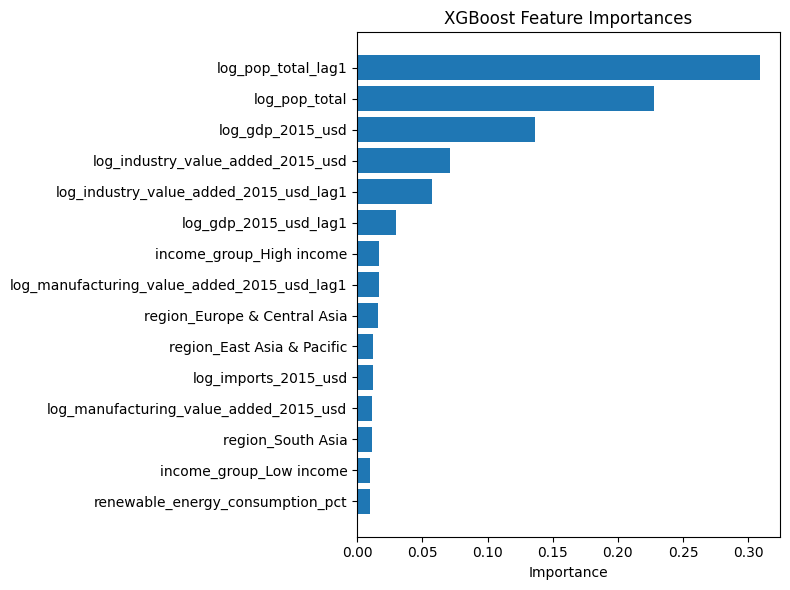

Running regression with group feature...

Cross-Validation Results:
------------------------------------------------------------------------------------------------------------------------
Model              Group MAE    (std)     Time MAE    (std)     Group R2    (std)      Time R2    (std)
------------------------------------------------------------------------------------------------------------------------
RandomForest          0.5538   0.0607       0.6224   0.0430       0.8336   0.0313       0.7805   0.0357
XGBoost               0.5261   0.0281       0.6263   0.0523       0.8625   0.0304       0.7979   0.0367
ElasticNet            0.5610   0.0372       0.5825   0.0737       0.8510   0.0451       0.8231   0.0730
Median                1.5254   0.1554       1.5295   0.1598      -0.0163   0.0178      -0.0417   0.0821

Evaluation Results:
--------------------------------------------------------------------------------
Model            Train MAE   Test MAE   Train R2    Test R2
--------

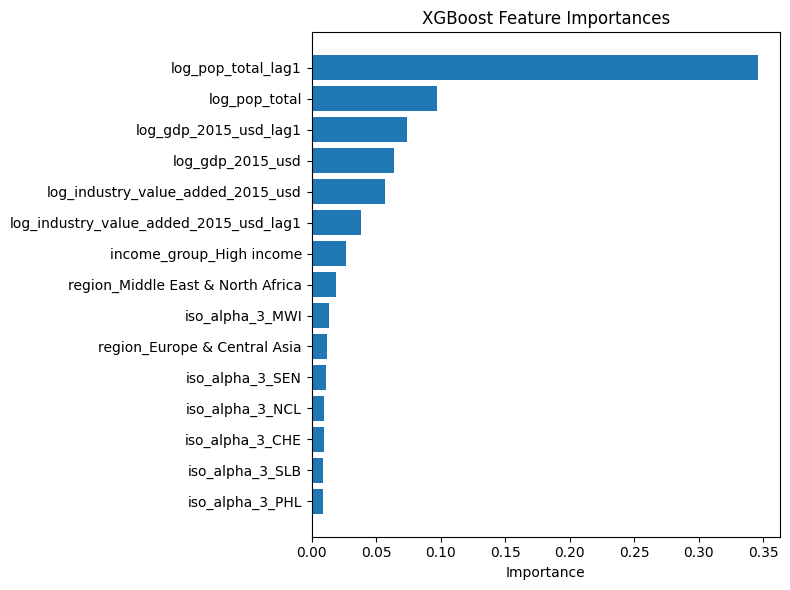

In [47]:
xgb_params = dict(
    n_estimators=300,      # Enough trees, not excessive for this size
    max_depth=4,           # Controls overfitting, 4–6 is common
    learning_rate=0.07,    # Slower learning, safer default than 0.1
    subsample=0.8,         # Row sampling for robustness
    colsample_bytree=0.8,  # Feature sampling per tree for robustness
    reg_alpha=0.2,         # L1 regularization, good for tabular data
    reg_lambda=1.0,        # L2 regularization (default 1.0, safe)
    random_state=42,       # For reproducibility
    n_jobs=-1,             # Use all cores
    verbosity=0
)

print("Running regression without group feature...")

reg_no_isos = RegressionAnalysis(training_df_log_transformed,
                            target_col="log_total_emissions",
                            group_col="iso_alpha_3",
                            year_col="year",
                            scaler_type="minmax",
                            use_group_feature=False,
                            xgb_params=xgb_params
                            )

reg_no_isos.run_all(plot_importances=True, importances_model='xgboost')

print("Running regression with group feature...")

reg_with_isos = RegressionAnalysis(training_df_log_transformed,
                           target_col="log_total_emissions",
                           group_col="iso_alpha_3",
                           year_col="year",
                           scaler_type="minmax",
                           use_group_feature=True,
                           xgb_params=xgb_params
                           )

reg_with_isos.run_all(plot_importances=True, importances_model='xgboost')

## Create projections

In [48]:
from utils.ml_utils_v2 import EnsembleProjections
ep = EnsembleProjections()

In [49]:
training_df_log_transformed.head()

,iso_alpha_3,income_group,region,year,renewable_energy_consumption_pct,forest_area_pct,log_pop_total,log_gdp_2015_usd,log_imports_2015_usd,log_industry_value_added_2015_usd,log_manufacturing_value_added_2015_usd,log_exports_2015_usd,log_total_emissions,log_gdp_2015_usd_lag1,log_imports_2015_usd_lag1,log_exports_2015_usd_lag1,log_industry_value_added_2015_usd_lag1,log_manufacturing_value_added_2015_usd_lag1,log_pop_total_lag1
0,ABW,High income,Latin America & Caribbean,2001,0.2,2.333333,11.423438,21.770632,21.494462,19.727498,18.481103,21.492709,0.295751,21.729663,21.494462,21.492709,19.727498,18.481103,11.414088
1,ABW,High income,Latin America & Caribbean,2002,0.2,2.333333,11.430359,21.761138,21.494462,19.727498,18.481103,21.492709,0.309851,21.770632,21.494462,21.492709,19.727498,18.481103,11.423438
2,ABW,High income,Latin America & Caribbean,2003,0.2,2.333333,11.441741,21.772182,21.494462,19.727498,18.481103,21.492709,0.345181,21.761138,21.494462,21.492709,19.727498,18.481103,11.430359
3,ABW,High income,Latin America & Caribbean,2004,0.2,2.333333,11.463094,21.842582,21.494462,19.727498,18.481103,21.492709,0.357805,21.772182,21.494462,21.492709,19.727498,18.481103,11.441741
4,ABW,High income,Latin America & Caribbean,2005,0.2,2.333333,11.489002,21.838743,21.494462,19.727498,18.481103,21.492709,0.380248,21.842582,21.494462,21.492709,19.727498,18.481103,11.463094


In [50]:
numeric_cols = training_df_log_transformed.select_dtypes(include=["float64", "int64"]).columns.tolist()
numeric_cols_to_drop = ["year", "log_total_emissions"]
numeric_cols = [col for col in numeric_cols if col not in numeric_cols_to_drop]
numeric_cols

['renewable_energy_consumption_pct',
 'forest_area_pct',
 'log_pop_total',
 'log_gdp_2015_usd',
 'log_imports_2015_usd',
 'log_industry_value_added_2015_usd',
 'log_manufacturing_value_added_2015_usd',
 'log_exports_2015_usd',
 'log_gdp_2015_usd_lag1',
 'log_imports_2015_usd_lag1',
 'log_exports_2015_usd_lag1',
 'log_industry_value_added_2015_usd_lag1',
 'log_manufacturing_value_added_2015_usd_lag1',
 'log_pop_total_lag1']

In [ ]:
n_scenarios = 10

ensemble_arima_df = ep.generate_ensemble_ts_lhs(
    df=training_df_log_transformed,
    feature_cols=numeric_cols,
    start_year=2022,
    end_year=2030,
    n_scenarios=n_scenarios,
    method="arima",          # or "ets"
    arima_order=(1,1,1),     # only used if method="arima"
    random_state=42
)


In [54]:
training_df_log_transformed.head()

,iso_alpha_3,income_group,region,year,renewable_energy_consumption_pct,forest_area_pct,log_pop_total,log_gdp_2015_usd,log_imports_2015_usd,log_industry_value_added_2015_usd,log_manufacturing_value_added_2015_usd,log_exports_2015_usd,log_total_emissions,log_gdp_2015_usd_lag1,log_imports_2015_usd_lag1,log_exports_2015_usd_lag1,log_industry_value_added_2015_usd_lag1,log_manufacturing_value_added_2015_usd_lag1,log_pop_total_lag1
0,ABW,High income,Latin America & Caribbean,2001,0.2,2.333333,11.423438,21.770632,21.494462,19.727498,18.481103,21.492709,0.295751,21.729663,21.494462,21.492709,19.727498,18.481103,11.414088
1,ABW,High income,Latin America & Caribbean,2002,0.2,2.333333,11.430359,21.761138,21.494462,19.727498,18.481103,21.492709,0.309851,21.770632,21.494462,21.492709,19.727498,18.481103,11.423438
2,ABW,High income,Latin America & Caribbean,2003,0.2,2.333333,11.441741,21.772182,21.494462,19.727498,18.481103,21.492709,0.345181,21.761138,21.494462,21.492709,19.727498,18.481103,11.430359
3,ABW,High income,Latin America & Caribbean,2004,0.2,2.333333,11.463094,21.842582,21.494462,19.727498,18.481103,21.492709,0.357805,21.772182,21.494462,21.492709,19.727498,18.481103,11.441741
4,ABW,High income,Latin America & Caribbean,2005,0.2,2.333333,11.489002,21.838743,21.494462,19.727498,18.481103,21.492709,0.380248,21.842582,21.494462,21.492709,19.727498,18.481103,11.463094


In [56]:
# Make sure ensemble_arima_df is sorted by iso_alpha_3 and year
ensemble_arima_df = ensemble_arima_df.sort_values(by=["iso_alpha_3", "year"]).reset_index(drop=True)
ensemble_arima_df.head()

,iso_alpha_3,future_id,year,renewable_energy_consumption_pct,forest_area_pct,log_pop_total,log_gdp_2015_usd,log_imports_2015_usd,log_industry_value_added_2015_usd,log_manufacturing_value_added_2015_usd,log_exports_2015_usd,log_gdp_2015_usd_lag1,log_imports_2015_usd_lag1,log_exports_2015_usd_lag1,log_industry_value_added_2015_usd_lag1,log_manufacturing_value_added_2015_usd_lag1,log_pop_total_lag1
0,ABW,id_ABW_1,2022,7.052790,2.333333,11.577592,21.734613,21.494463,19.727497,18.481103,21.492707,21.884877,21.494462,21.492710,19.727498,18.481105,11.580003
1,ABW,id_ABW_2,2022,8.147565,2.333334,11.583839,21.762643,21.494463,19.727498,18.481105,21.492710,21.775629,21.494463,21.492709,19.727498,18.481102,11.575524
2,ABW,id_ABW_3,2022,8.057343,2.333334,11.579244,21.819856,21.494462,19.727499,18.481104,21.492707,21.873571,21.494462,21.492710,19.727499,18.481104,11.583500
3,ABW,id_ABW_4,2022,8.981733,2.333334,11.584768,21.715132,21.494463,19.727497,18.481102,21.492710,21.899219,21.494463,21.492708,19.727500,18.481104,11.585799
4,ABW,id_ABW_5,2022,8.666764,2.333331,11.586537,21.925924,21.494463,19.727498,18.481102,21.492708,21.867987,21.494461,21.492709,19.727498,18.481103,11.584784


In [57]:
# Save the training and ensemble dataframes to csv files
training_df_log_transformed.to_csv(os.path.join(TRAINING_DIR_PATH, "training_df_log_transformed.csv"), index=False)
training_df_lags.to_csv(os.path.join(TRAINING_DIR_PATH, "training_df_lags.csv"), index=False)
ensemble_arima_df.to_csv(os.path.join(ENSEMBLE_DIR_PATH, f"ensemble_arima_{n_scenarios}_df.csv"), index=False)


# Save the trained models
trained_pipelines = {
    "reg_with_isos_xgb": reg_with_isos.pipe_xgb,
    "reg_with_isos_enet": reg_with_isos.pipe_enet,
    "reg_no_isos_xgb": reg_no_isos.pipe_xgb,
    "reg_no_isos_enet": reg_no_isos.pipe_enet
}


for name, pipeline in trained_pipelines.items():
    model_file_name = f"{name}_pipeline.pkl"
    MODEL_PATH = os.path.join(MODELS_DIR_PATH, model_file_name)
    if os.path.exists(MODEL_PATH):
        print(f"Model {model_file_name} already exists at {MODEL_PATH}. Make sure you don't overwrite an existing model.")
    else:
        print(f"Saving model {model_file_name} to {MODEL_PATH}.")
        joblib.dump(pipeline, MODEL_PATH)

Model reg_with_isos_xgb_pipeline.pkl already exists at /home/tony-ubuntu/decision_sciences/etpe_project/ml_scripts/output/models/reg_with_isos_xgb_pipeline.pkl. Make sure you don't overwrite an existing model.
Model reg_with_isos_enet_pipeline.pkl already exists at /home/tony-ubuntu/decision_sciences/etpe_project/ml_scripts/output/models/reg_with_isos_enet_pipeline.pkl. Make sure you don't overwrite an existing model.
Model reg_no_isos_xgb_pipeline.pkl already exists at /home/tony-ubuntu/decision_sciences/etpe_project/ml_scripts/output/models/reg_no_isos_xgb_pipeline.pkl. Make sure you don't overwrite an existing model.
Model reg_no_isos_enet_pipeline.pkl already exists at /home/tony-ubuntu/decision_sciences/etpe_project/ml_scripts/output/models/reg_no_isos_enet_pipeline.pkl. Make sure you don't overwrite an existing model.
